In [0]:
from pyspark.sql.functions import col
appointments_data = [
(1001, "Hyderabad", "Cardiology", "Apollo", 1500, "Completed"),
(1002, "Bangalore", "Neurology", "Yashoda", 2200, "Completed"),
(1003, "Mumbai", "Dermatology", "Care", 900, "Pending"),
(1004, "Delhi", "Orthopedics", "Max", 2500, "Completed"),
(1005, "Chennai", "Pediatrics", "Apollo", 1200, "Cancelled"),
(1006, "Hyderabad", "Cardiology", "Care", 3000, "Completed"),
(1007, "Bangalore", "Dermatology", "Apollo", 1000, "Completed"),
(1008, "Mumbai", "Neurology", "Max", 2600, "Pending"),
(1009, "Delhi", "Cardiology", "Yashoda", 2800, "Completed"),
(1010, "Chennai", "Orthopedics", "Care", 2400, "Completed"),
(1011, "Hyderabad", "Pediatrics", "Apollo", 1100, "Completed"),
(1012, "Bangalore", "Cardiology", "Max", 3200, "Completed"),
(1013, "Mumbai", "Pediatrics", "Yashoda", 1300, "Cancelled"),
(1014, "Delhi", "Neurology", "Apollo", 2700, "Completed"),
(1015, "Chennai", "Dermatology", "Care", 950, "Pending")
]
columns = [
"appointment_id",
"city",
"department",
"hospital",
"consultation_fee",
"status"
]
df = spark.createDataFrame(appointments_data, columns)
display(df)

appointment_id,city,department,hospital,consultation_fee,status
1001,Hyderabad,Cardiology,Apollo,1500,Completed
1002,Bangalore,Neurology,Yashoda,2200,Completed
1003,Mumbai,Dermatology,Care,900,Pending
1004,Delhi,Orthopedics,Max,2500,Completed
1005,Chennai,Pediatrics,Apollo,1200,Cancelled
1006,Hyderabad,Cardiology,Care,3000,Completed
1007,Bangalore,Dermatology,Apollo,1000,Completed
1008,Mumbai,Neurology,Max,2600,Pending
1009,Delhi,Cardiology,Yashoda,2800,Completed
1010,Chennai,Orthopedics,Care,2400,Completed


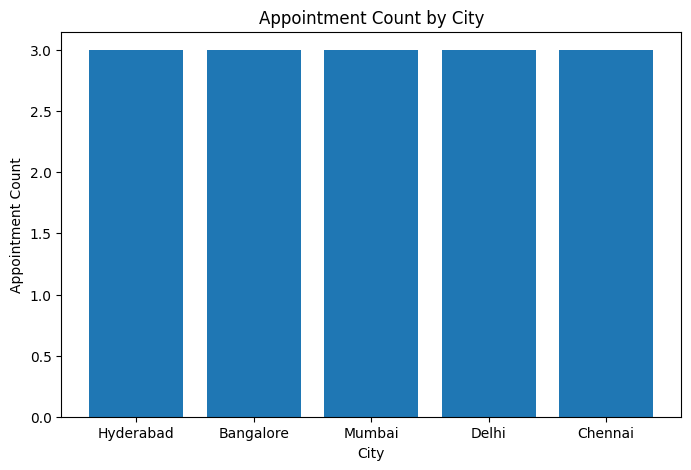

In [0]:
city_count = df.groupBy("city").count().toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(city_count["city"], city_count["count"])
plt.title("Appointment Count by City")
plt.xlabel("City")
plt.ylabel("Appointment Count")
plt.show()

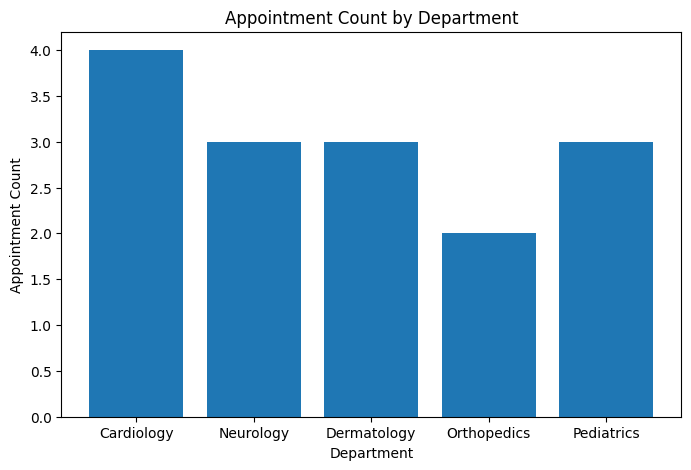

In [0]:
dept_count = df.groupBy("department").count().toPandas()

plt.figure(figsize=(8,5))
plt.bar(dept_count["department"], dept_count["count"])
plt.title("Appointment Count by Department")
plt.xlabel("Department")
plt.ylabel("Appointment Count")
plt.show()

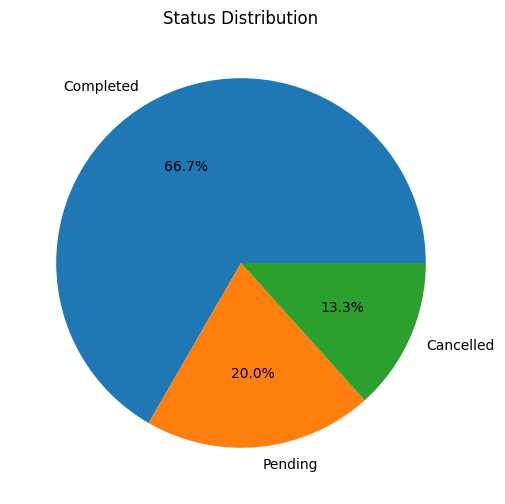

In [0]:
status_count = df.groupBy("status").count().toPandas()

plt.figure(figsize=(6,6))
plt.pie(status_count["count"],
        labels=status_count["status"],
        autopct="%1.1f%%")
plt.title("Status Distribution")
plt.show()

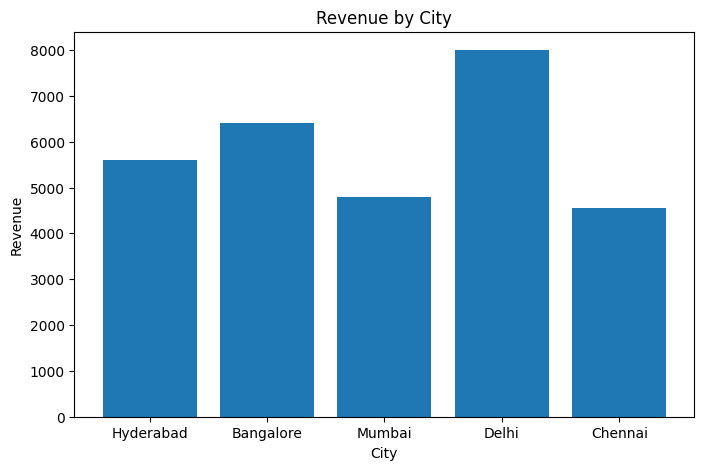

In [0]:
revenue_city = df.groupBy("city").sum("consultation_fee") \
                 .withColumnRenamed("sum(consultation_fee)","revenue") \
                 .toPandas()

plt.figure(figsize=(8,5))
plt.bar(revenue_city["city"], revenue_city["revenue"])
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.show()

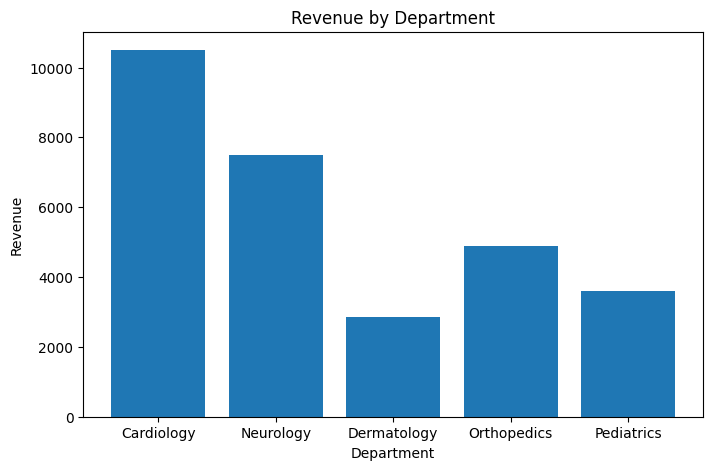

In [0]:
revenue_dept = df.groupBy("department").sum("consultation_fee") \
                 .withColumnRenamed("sum(consultation_fee)","revenue") \
                 .toPandas()

plt.figure(figsize=(8,5))
plt.bar(revenue_dept["department"], revenue_dept["revenue"])
plt.title("Revenue by Department")
plt.xlabel("Department")
plt.ylabel("Revenue")
plt.show()

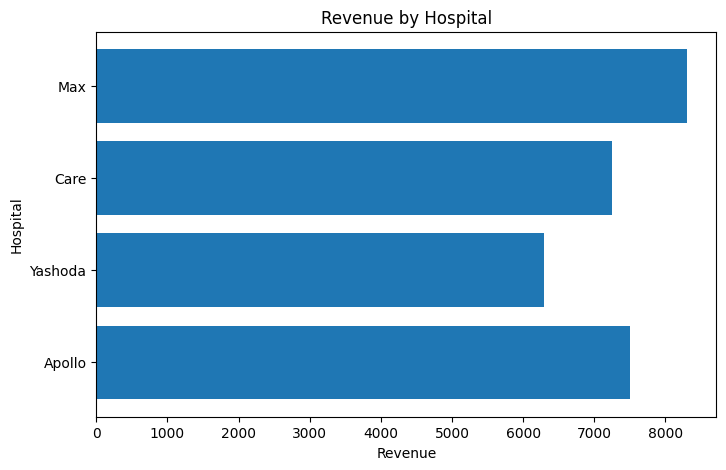

In [0]:
revenue_hospital = df.groupBy("hospital").sum("consultation_fee") \
                     .withColumnRenamed("sum(consultation_fee)","revenue") \
                     .toPandas()

plt.figure(figsize=(8,5))
plt.barh(revenue_hospital["hospital"], revenue_hospital["revenue"])
plt.title("Revenue by Hospital")
plt.xlabel("Revenue")
plt.ylabel("Hospital")
plt.show()

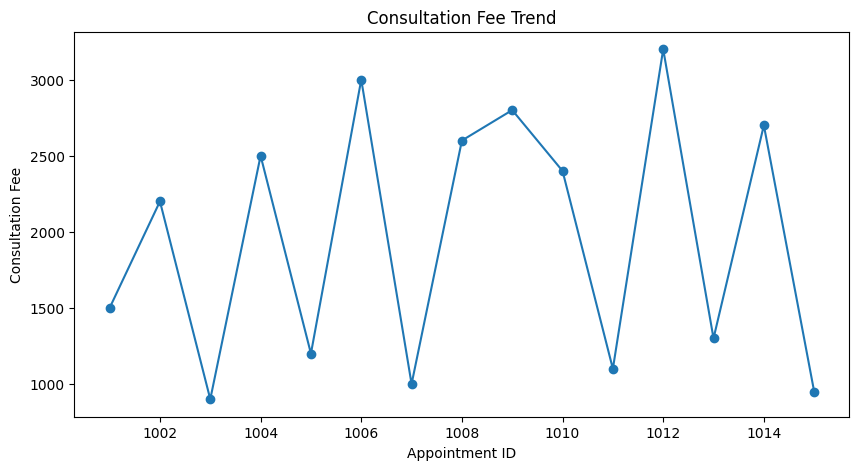

In [0]:
fee_trend = df.orderBy("appointment_id").toPandas()

plt.figure(figsize=(10,5))
plt.plot(fee_trend["appointment_id"],
         fee_trend["consultation_fee"],
         marker="o")
plt.title("Consultation Fee Trend")
plt.xlabel("Appointment ID")
plt.ylabel("Consultation Fee")
plt.show()

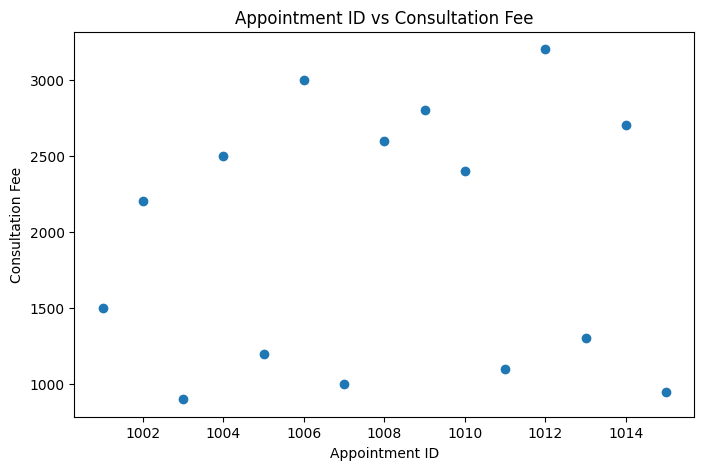

In [0]:
pdf = df.toPandas()

plt.figure(figsize=(8,5))
plt.scatter(pdf["appointment_id"],
            pdf["consultation_fee"])
plt.title("Appointment ID vs Consultation Fee")
plt.xlabel("Appointment ID")
plt.ylabel("Consultation Fee")
plt.show()

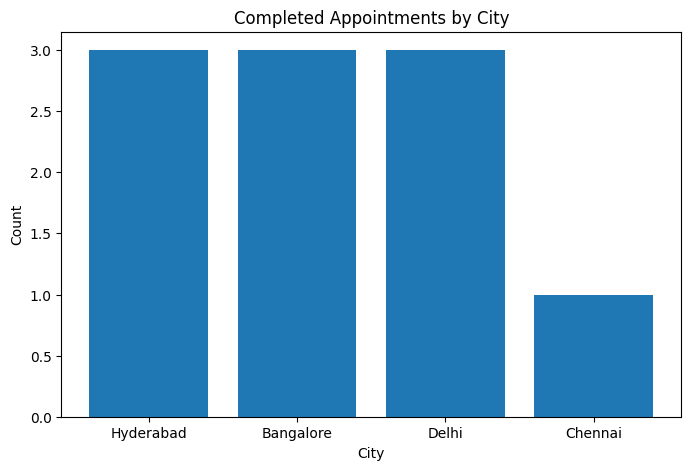

In [0]:
completed = df.filter(col("status")=="Completed")

completed_city = completed.groupBy("city").count().toPandas()

plt.figure(figsize=(8,5))
plt.bar(completed_city["city"], completed_city["count"])
plt.title("Completed Appointments by City")
plt.xlabel("City")
plt.ylabel("Count")
plt.show()

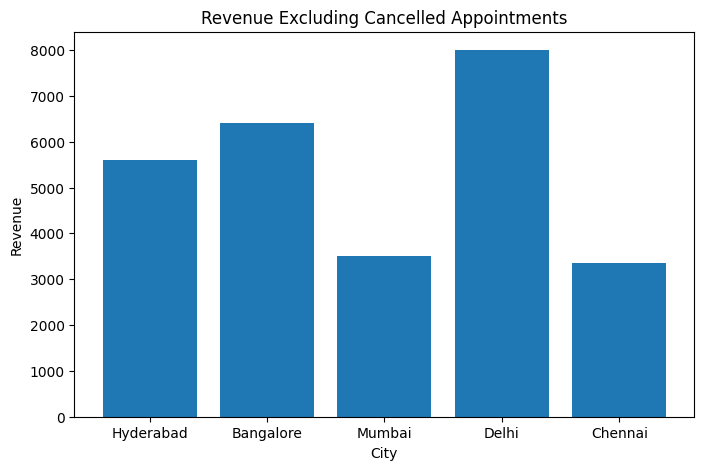

In [0]:
active = df.filter(col("status")!="Cancelled")

revenue = active.groupBy("city").sum("consultation_fee") \
                .withColumnRenamed("sum(consultation_fee)","revenue") \
                .toPandas()

plt.figure(figsize=(8,5))
plt.bar(revenue["city"], revenue["revenue"])
plt.title("Revenue Excluding Cancelled Appointments")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.show()

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

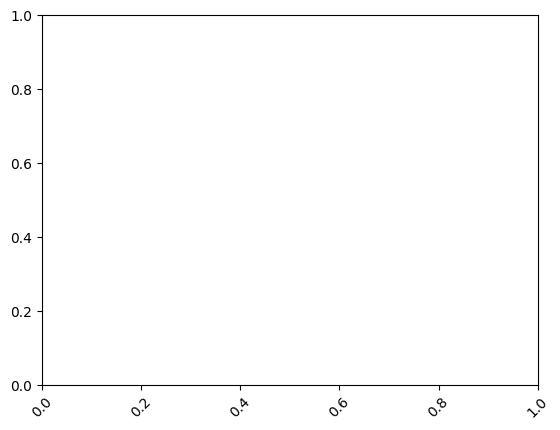

In [0]:
plt.xticks(rotation=45)

Text(0.5, 1.0, 'Hospital Revenue Analysis')

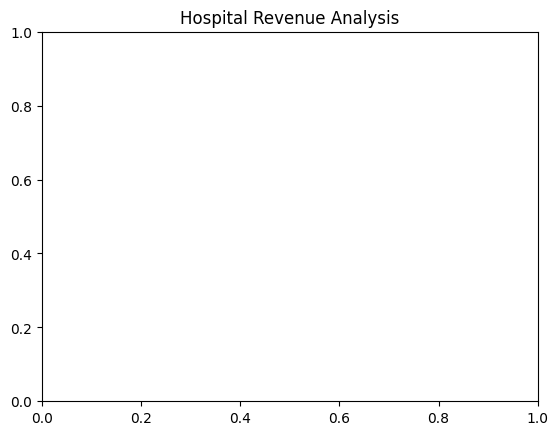

In [0]:
plt.title("Hospital Revenue Analysis")

Text(0.5, 0, 'Hospital Name')

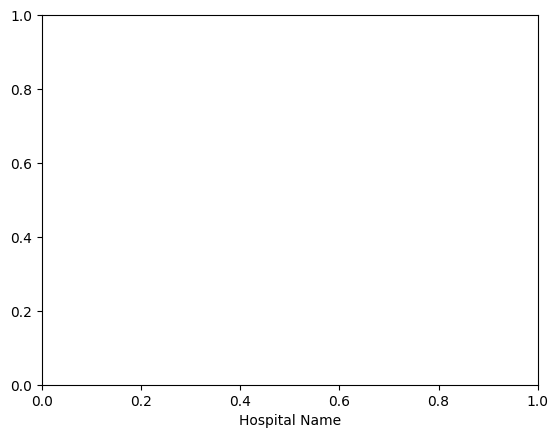

In [0]:
plt.xlabel("Hospital Name")

Text(0, 0.5, 'Total Revenue')

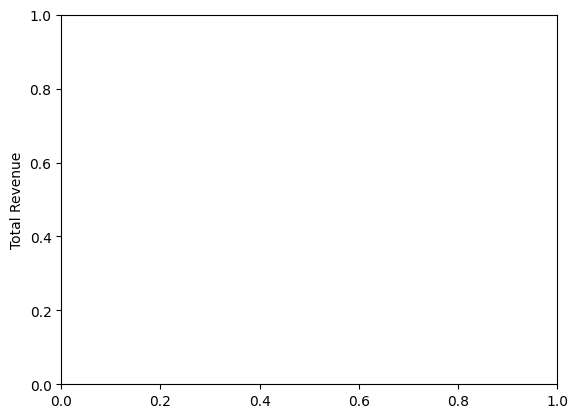

In [0]:
plt.ylabel("Total Revenue")

In [0]:
plt.figure(figsize=(12,6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [0]:
df.groupBy("city") \
  .sum("consultation_fee") \
  .withColumnRenamed("sum(consultation_fee)","revenue") \
  .orderBy(col("revenue").desc()) \
  .show(3)

+---------+-------+
|     city|revenue|
+---------+-------+
|    Delhi|   8000|
|Bangalore|   6400|
|Hyderabad|   5600|
+---------+-------+
only showing top 3 rows


In [0]:
df.groupBy("department") \
  .sum("consultation_fee") \
  .withColumnRenamed("sum(consultation_fee)","revenue") \
  .orderBy(col("revenue").desc()) \
  .show(3)

+-----------+-------+
| department|revenue|
+-----------+-------+
| Cardiology|  10500|
|  Neurology|   7500|
|Orthopedics|   4900|
+-----------+-------+
only showing top 3 rows


In [0]:
df.groupBy("hospital") \
  .sum("consultation_fee") \
  .withColumnRenamed("sum(consultation_fee)","revenue") \
  .orderBy(col("revenue")) \
  .show(1)

+--------+-------+
|hospital|revenue|
+--------+-------+
| Yashoda|   6300|
+--------+-------+
only showing top 1 row


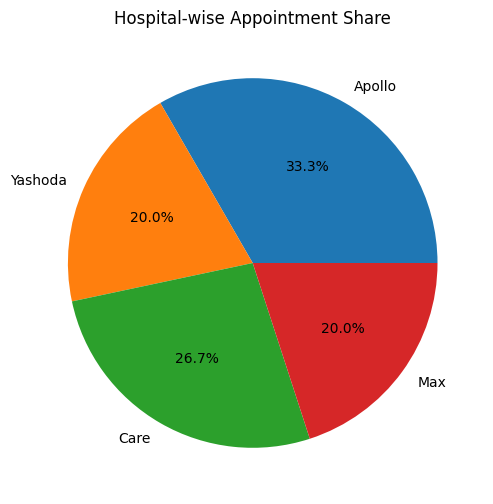

In [0]:
hospital_count = df.groupBy("hospital").count().toPandas()

plt.figure(figsize=(6,6))
plt.pie(hospital_count["count"],
        labels=hospital_count["hospital"],
        autopct="%1.1f%%")
plt.title("Hospital-wise Appointment Share")
plt.show()

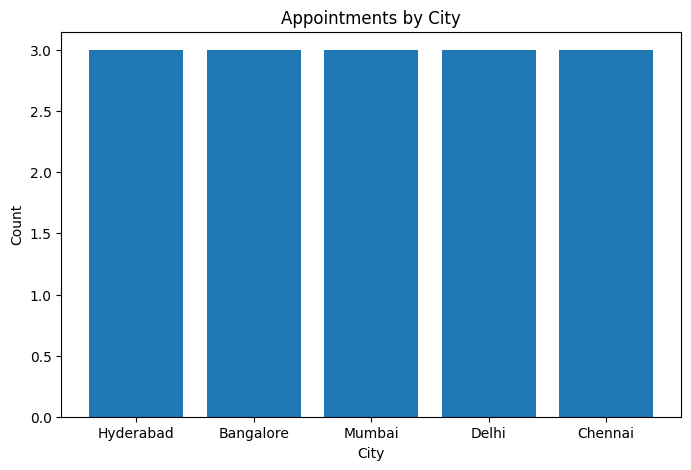

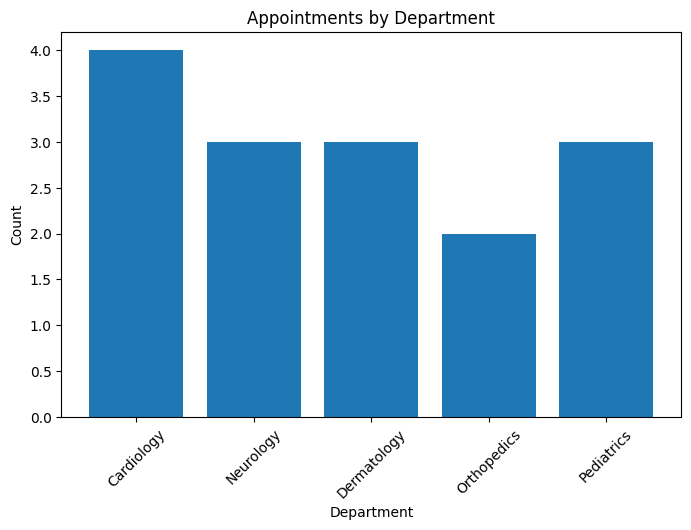

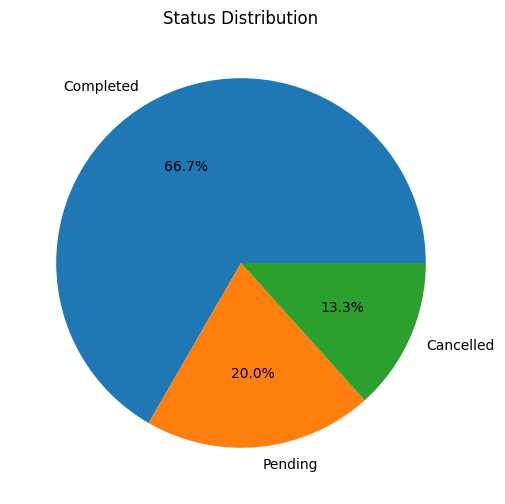

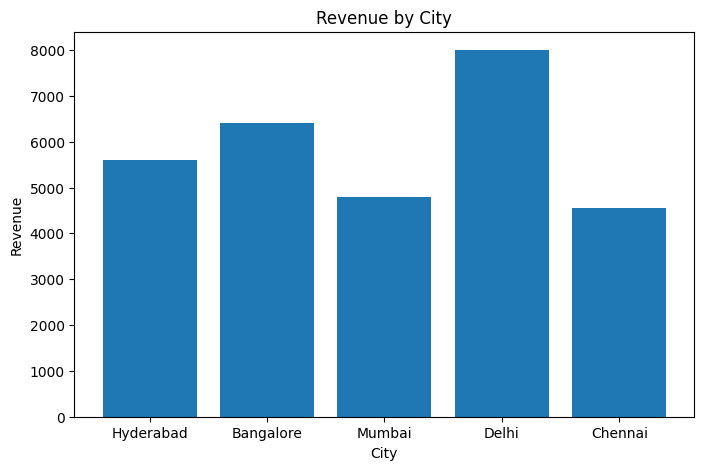

In [0]:
import matplotlib.pyplot as plt

# Chart 1
city_count = df.groupBy("city").count().toPandas()

plt.figure(figsize=(8,5))
plt.bar(city_count["city"], city_count["count"])
plt.title("Appointments by City")
plt.xlabel("City")
plt.ylabel("Count")
plt.show()

# Chart 2
dept_count = df.groupBy("department").count().toPandas()

plt.figure(figsize=(8,5))
plt.bar(dept_count["department"], dept_count["count"])
plt.title("Appointments by Department")
plt.xlabel("Department")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Chart 3
status_count = df.groupBy("status").count().toPandas()

plt.figure(figsize=(6,6))
plt.pie(status_count["count"],
        labels=status_count["status"],
        autopct="%1.1f%%")
plt.title("Status Distribution")
plt.show()

# Chart 4
revenue_city = df.groupBy("city").sum("consultation_fee") \
                 .withColumnRenamed("sum(consultation_fee)","revenue") \
                 .toPandas()

plt.figure(figsize=(8,5))
plt.bar(revenue_city["city"], revenue_city["revenue"])
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.show()